# Challenge 5 — Group 3: Public Health & Epidemiology
## Notebook 01 — Exploratory Data Analysis (EDA)
**Dataset:** CDC BRFSS 2023  
**Source:** https://www.cdc.gov/brfss/annual_data/annual_2023.html

**Goal:** Load the raw data, select a meaningful feature subset, understand distributions,
identify missing values, and prepare a clean snapshot for preprocessing.

---

## 1. Imports & Configuration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Plot style ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Paths ────────────────────────────────────────────────────────
DATA_PATH   = '../data/LLCP2024XPT/LLCP2024.XPT'
FIG_PATH    = '../figures/'

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load the Raw Dataset

The BRFSS 2024 file is in SAS Transport format (`.XPT`).  
pandas reads it natively with `read_sas()`. This may take ~30–60 seconds.

In [6]:
import pyreadstat

CLUSTER_VARS = {
    '_SMOKER3'  : 'smoking_status',
    'DRNKANY6'  : 'alcohol_any',
    'DRNK3GE5'  : 'binge_drinking',
    '_TOTINDA'  : 'physical_activity',
    'FRUTSU1_'  : 'fruit_per_day',
    'VEGSU1_'   : 'veg_per_day',
    'SLEPTIM1'  : 'sleep_hours',
    '_BMI5'     : 'bmi',
    'DIABETE4'  : 'diabetes',
    '_RFHYPE6'  : 'hypertension',
    'TOLDHI3'   : 'high_cholesterol',
    'CVDCRHD4'  : 'coronary_heart_disease',
    'ASTHMA3'   : 'asthma',
    'CHCCOPD3'  : 'copd',
    'ADDEPEV3'  : 'depression',
    'CHECKUP1'  : 'last_checkup',
    'FLUSHOT7'  : 'flu_vaccine',
    'PNEUVAC4'  : 'pneumo_vaccine',
}

DEMO_VARS = {
    '_AGEG5YR'  : 'age_group',
    'SEXVAR'    : 'sex',
    '_EDUCAG'   : 'education',
    '_INCOMG1'  : 'income_group',
    '_RACEG21'  : 'race',
    '_STATE'    : 'state',
}

ALL_COLS_RAW = list(CLUSTER_VARS.keys()) + list(DEMO_VARS.keys())

print('Loading BRFSS XPT file (selected columns only)...')
df_raw, meta = pyreadstat.read_xport(DATA_PATH, usecols=ALL_COLS_RAW)

print(f'✅ Loaded successfully!')
print(f'   Rows    : {df_raw.shape[0]:,}')
print(f'   Columns : {df_raw.shape[1]:,}')

Loading BRFSS XPT file (selected columns only)...
✅ Loaded successfully!
   Rows    : 457,670
   Columns : 19


---
## 3. Feature Selection

BRFSS 2024 has ~350 columns. We select a **focused, domain-motivated subset** of
~20 variables covering four categories:

| Category | Purpose |
|---|---|
| **Health behaviors** | Core clustering signal |
| **Chronic conditions** | Outcome proxies for interpretation |
| **Preventive care** | Healthcare access indicators |
| **Demographics** | Used only for cluster interpretation, not as clustering features |

> **Key rule:** Demographic variables (age, sex, race) are kept separate and used
> *only* to describe clusters after the fact — never as clustering inputs.
> This ensures we discover behavioral archetypes, not demographic segments.

In [8]:
# ── Variables selected for CLUSTERING (behavioral + conditions + care) ──────
CLUSTER_VARS = {
    # --- Health Behaviors ---
    '_SMOKER3'  : 'smoking_status',       # 1=daily, 2=someday, 3=former, 4=never
    'DRNKANY6'  : 'alcohol_any',          # 1=yes, 2=no (any drinks in past 30 days)
    'DRNK3GE5'  : 'binge_drinking',       # # of binge-drinking occasions
    '_TOTINDA'  : 'physical_activity',    # 1=yes, 2=no (any PA in past 30 days)
    'FRUTSU1_'  : 'fruit_per_day',        # computed times fruit consumed per day
    'VEGSU1_'   : 'veg_per_day',          # computed times vegetables per day
    'SLEPTIM1'  : 'sleep_hours',          # hours of sleep per night
    '_BMI5'     : 'bmi',                  # body-mass index (×100)

    # --- Chronic Conditions ---
    'DIABETE4'  : 'diabetes',             # 1=yes, 2=pre-diabetes, 3=no, 4=only gestational
    '_RFHYPE6'  : 'hypertension',         # 1=no, 2=yes
    'TOLDHI3'   : 'high_cholesterol',     # 1=yes, 2=no
    'CVDCRHD4'  : 'coronary_heart_disease', # 1=yes, 2=no
    'ASTHMA3'   : 'asthma',              # 1=yes, 2=no
    'CHCCOPD3'  : 'copd',                # 1=yes, 2=no
    'ADDEPEV3'  : 'depression',          # 1=yes, 2=no

    # --- Preventive Care ---
    'CHECKUP1'  : 'last_checkup',         # 1=<1yr, 2=1-2yr, 3=2-5yr, 4=>5yr, 8=never
    'FLUSHOT7'  : 'flu_vaccine',          # 1=yes, 2=no
    'PNEUVAC4'  : 'pneumo_vaccine',       # 1=yes, 2=no
}

# ── Demographic variables (for INTERPRETATION only) ─────────────────────────
DEMO_VARS = {
    '_AGEG5YR'  : 'age_group',            # 1-13 age categories
    'SEXVAR'    : 'sex',                  # 1=male, 2=female
    '_EDUCAG'   : 'education',            # 1=<HS, 2=HS grad, 3=some college, 4=college grad
    '_INCOMG1'  : 'income_group',         # 1-7 income categories
    '_RACEG21'  : 'race',                 # 1=white, 2=Black, 3=other, 4=multiracial
    '_STATE'    : 'state',                # FIPS state code
}

ALL_VARS = {**CLUSTER_VARS, **DEMO_VARS}

# Select only those columns that actually exist in the dataset
available = [col for col in ALL_VARS.keys() if col in df_raw.columns]
missing_cols = [col for col in ALL_VARS.keys() if col not in df_raw.columns]

print(f'Requested : {len(ALL_VARS)} variables')
print(f'Found     : {len(available)} variables')
if missing_cols:
    print(f'Not found : {missing_cols}')
    print('  → These may have different names in the 2024 codebook; we will drop them.')

Requested : 24 variables
Found     : 19 variables
Not found : ['FRUTSU1_', 'VEGSU1_', 'SLEPTIM1', '_RFHYPE6', 'TOLDHI3']
  → These may have different names in the 2024 codebook; we will drop them.


In [9]:
# Build working dataframe with readable column names
df = df_raw[available].copy()
df.rename(columns={k: v for k, v in ALL_VARS.items() if k in available}, inplace=True)

print('Working dataframe shape:', df.shape)
df.head(3)

Working dataframe shape: (457670, 19)


,smoking_status,alcohol_any,binge_drinking,physical_activity,bmi,diabetes,coronary_heart_disease,asthma,copd,depression,last_checkup,flu_vaccine,pneumo_vaccine,age_group,sex,education,income_group,race,state
0,4.0,2.0,NaN,1.0,2249.0,3.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,12.0,2.0,2.0,9.0,1.0,1.0
1,3.0,2.0,NaN,1.0,2583.0,3.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,13.0,1.0,4.0,7.0,1.0,1.0
2,1.0,1.0,3.0,1.0,2253.0,3.0,2.0,2.0,2.0,2.0,4.0,2.0,2.0,8.0,1.0,3.0,9.0,1.0,1.0


---
## 4. Missing Value Analysis

In BRFSS, missing values are encoded as **high sentinel numbers** (e.g., 7=Don't know,
9=Refused, 77/99/777/999 for continuous vars). We must recode these as `NaN` *before*
computing any missing-value statistics.

In [10]:
# ── Recode BRFSS sentinel values to NaN ─────────────────────────────────────
# Binary/ordinal variables: 7=don't know, 9=refused
BINARY_COLS = [
    'smoking_status', 'alcohol_any', 'physical_activity',
    'diabetes', 'hypertension', 'high_cholesterol',
    'coronary_heart_disease', 'asthma', 'copd', 'depression',
    'last_checkup', 'flu_vaccine', 'pneumo_vaccine',
]

# Continuous variables: 77/99 or 777/999 = don't know / refused
CONTINUOUS_COLS = ['sleep_hours', 'binge_drinking', 'fruit_per_day', 'veg_per_day']

for col in BINARY_COLS:
    if col in df.columns:
        df[col] = df[col].replace([7, 9, 77, 99], np.nan)

for col in CONTINUOUS_COLS:
    if col in df.columns:
        df[col] = df[col].replace([77, 99, 777, 999], np.nan)

# BMI is stored ×100 in BRFSS — convert to standard BMI
if 'bmi' in df.columns:
    df['bmi'] = df['bmi'] / 100
    df['bmi'] = df['bmi'].replace([0], np.nan)  # 0 = missing for BMI

print('Sentinel values recoded to NaN ✅')

Sentinel values recoded to NaN ✅


                        Missing Count  Missing %
binge_drinking                 250675      54.77
pneumo_vaccine                  73859      16.14
flu_vaccine                     44366       9.69
alcohol_any                     43777       9.57
bmi                             43037       9.40
smoking_status                  32022       7.00
last_checkup                     5334       1.17
coronary_heart_disease           4578       1.00
depression                       2664       0.58
copd                             2174       0.48
asthma                           1861       0.41
physical_activity                1315       0.29
diabetes                         1034       0.23
age_group                           0       0.00
sex                                 0       0.00
education                           0       0.00
income_group                        0       0.00
race                                0       0.00
state                               0       0.00


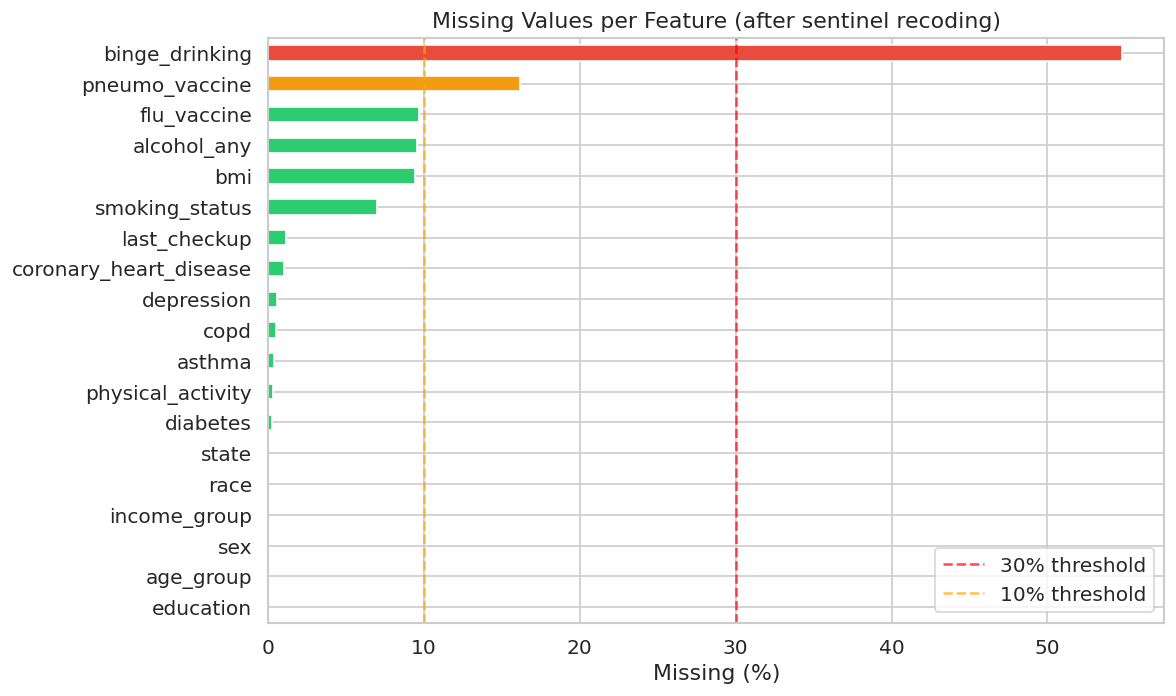

Figure saved: figures/missing_values.png


In [11]:
# ── Missing value summary ────────────────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df.to_string())

# Visual
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if p > 30 else '#f39c12' if p > 10 else '#2ecc71'
          for p in missing_pct]
missing_pct.sort_values(ascending=True).plot(
    kind='barh', ax=ax, color=colors[::-1]
)
ax.axvline(30, color='red', linestyle='--', alpha=0.7, label='30% threshold')
ax.axvline(10, color='orange', linestyle='--', alpha=0.7, label='10% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Feature (after sentinel recoding)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_PATH}missing_values.png')
plt.show()
print('Figure saved: figures/missing_values.png')

---
## 5. Distribution Analysis — Clustering Features

We inspect each clustering variable to understand its scale, skew, and value range.
This informs our preprocessing strategy in Notebook 02.

In [12]:
# ── Summary statistics for clustering features ───────────────────────────────
cluster_cols = [v for v in CLUSTER_VARS.values() if v in df.columns]
df[cluster_cols].describe().round(2)

,smoking_status,alcohol_any,binge_drinking,physical_activity,bmi,diabetes,coronary_heart_disease,asthma,copd,depression,last_checkup,flu_vaccine,pneumo_vaccine
count,425648.00,413893.00,206995.00,456355.00,414633.00,456636.00,453092.00,455809.00,455496.00,455006.00,452336.00,413304.00,383811.00
mean,3.42,1.49,65.89,1.23,28.56,2.73,1.94,1.84,1.92,1.79,1.35,1.52,1.56
std,0.88,0.50,36.94,0.42,6.59,0.73,0.24,0.36,0.27,0.41,0.91,0.50,0.50
min,1.00,1.00,1.00,1.00,12.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,3.00,1.00,20.00,1.00,24.14,3.00,2.00,2.00,2.00,2.00,1.00,1.00,1.00
50%,4.00,1.00,88.00,1.00,27.44,3.00,2.00,2.00,2.00,2.00,1.00,2.00,2.00
75%,4.00,2.00,88.00,1.00,31.75,3.00,2.00,2.00,2.00,2.00,1.00,2.00,2.00
max,4.00,2.00,88.00,2.00,99.84,4.00,2.00,2.00,2.00,2.00,8.00,2.00,2.00


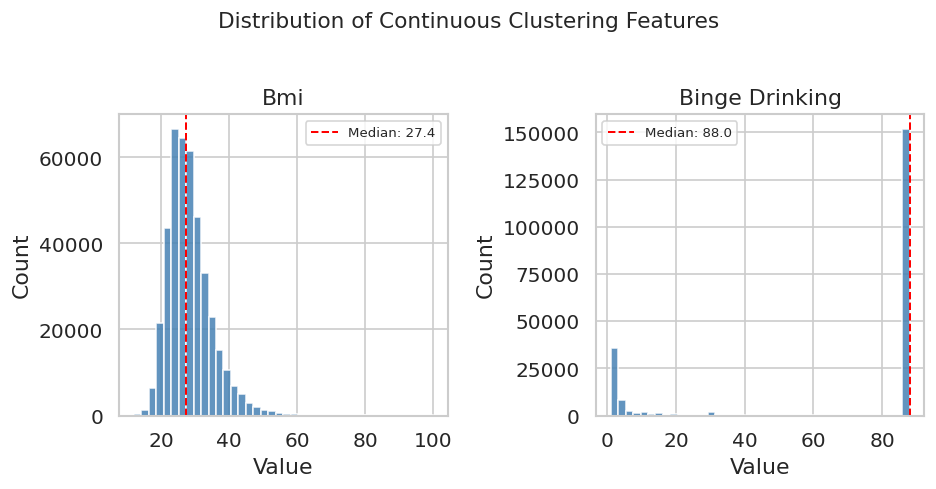

Figure saved: figures/distributions_continuous.png


In [13]:
# ── Distribution plots — continuous variables ────────────────────────────────
continuous_cluster = ['bmi', 'sleep_hours', 'fruit_per_day', 'veg_per_day', 'binge_drinking']
continuous_cluster = [c for c in continuous_cluster if c in df.columns]

fig, axes = plt.subplots(1, len(continuous_cluster), figsize=(4 * len(continuous_cluster), 4))

for ax, col in zip(axes, continuous_cluster):
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Continuous Clustering Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}distributions_continuous.png', bbox_inches='tight')
plt.show()
print('Figure saved: figures/distributions_continuous.png')

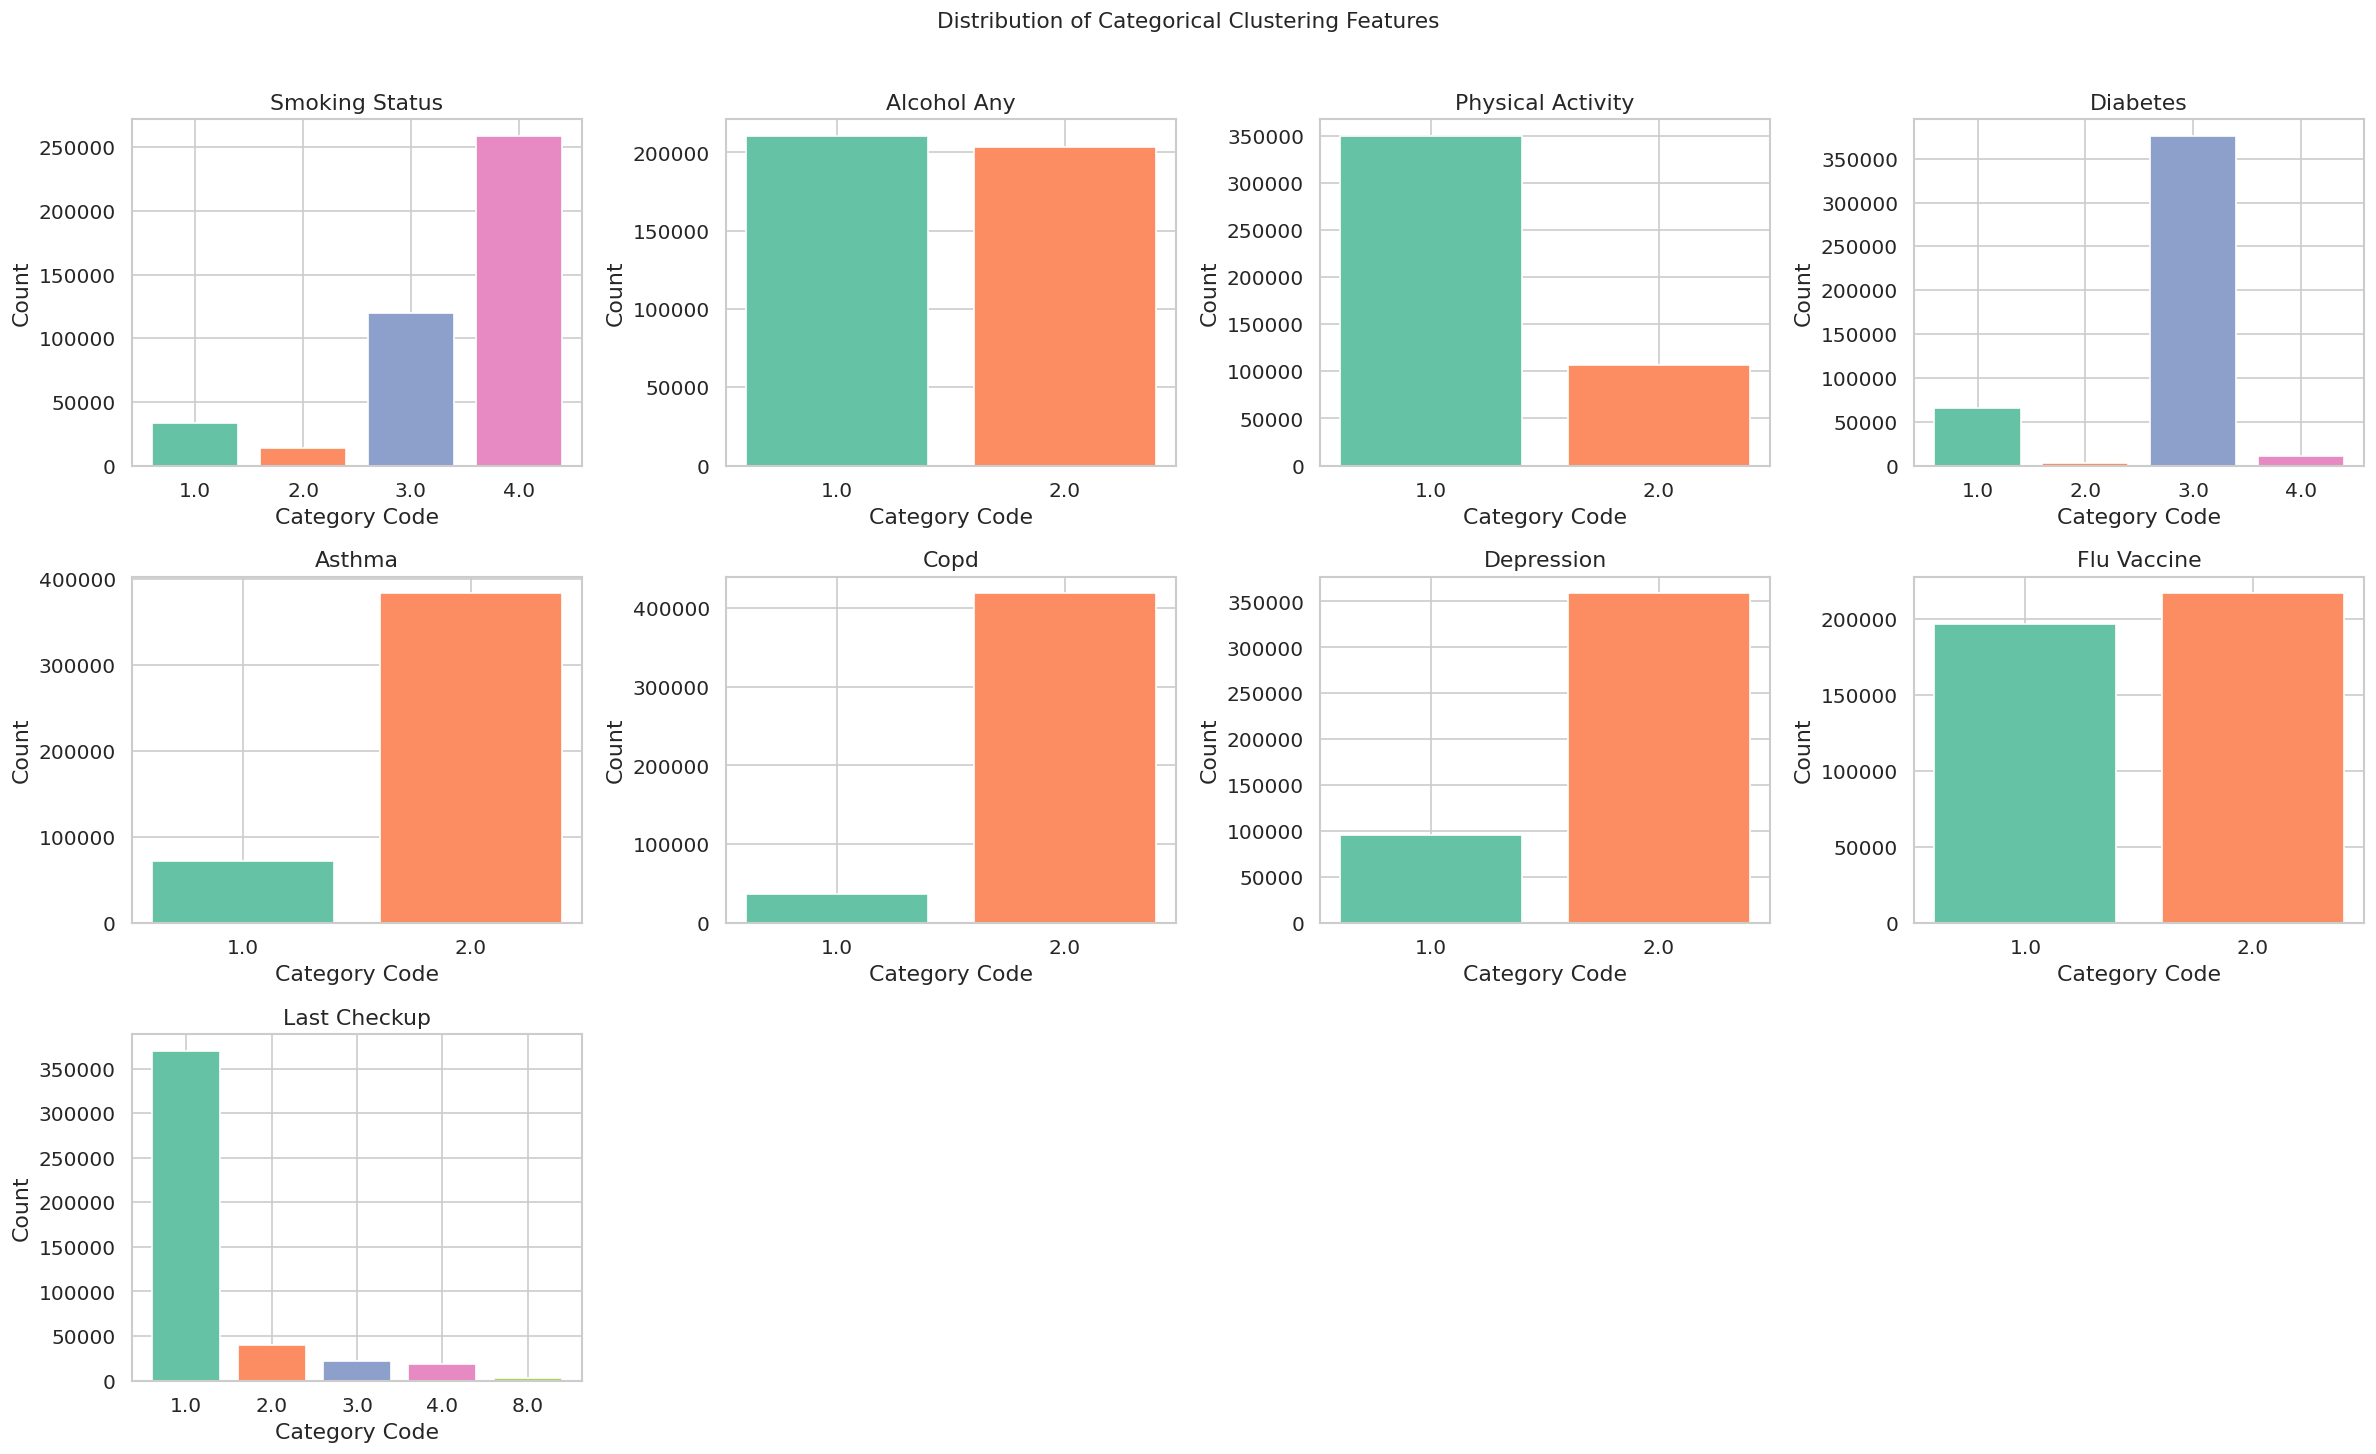

Figure saved: figures/distributions_categorical.png


In [14]:
# ── Distribution plots — categorical/binary variables ────────────────────────
cat_cluster = [
    'smoking_status', 'alcohol_any', 'physical_activity',
    'diabetes', 'hypertension', 'high_cholesterol',
    'asthma', 'copd', 'depression', 'flu_vaccine',
    'last_checkup'
]
cat_cluster = [c for c in cat_cluster if c in df.columns]

n_cols = 4
n_rows = int(np.ceil(len(cat_cluster) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cluster):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=sns.color_palette('Set2', len(counts)))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Category Code')
    ax.set_ylabel('Count')

# Turn off unused subplots
for ax in axes[len(cat_cluster):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Categorical Clustering Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}distributions_categorical.png', bbox_inches='tight')
plt.show()
print('Figure saved: figures/distributions_categorical.png')

---
## 6. Outlier Detection — Continuous Variables

Before clustering, we need to understand extreme values.
We use boxplots and the IQR rule to flag outliers.

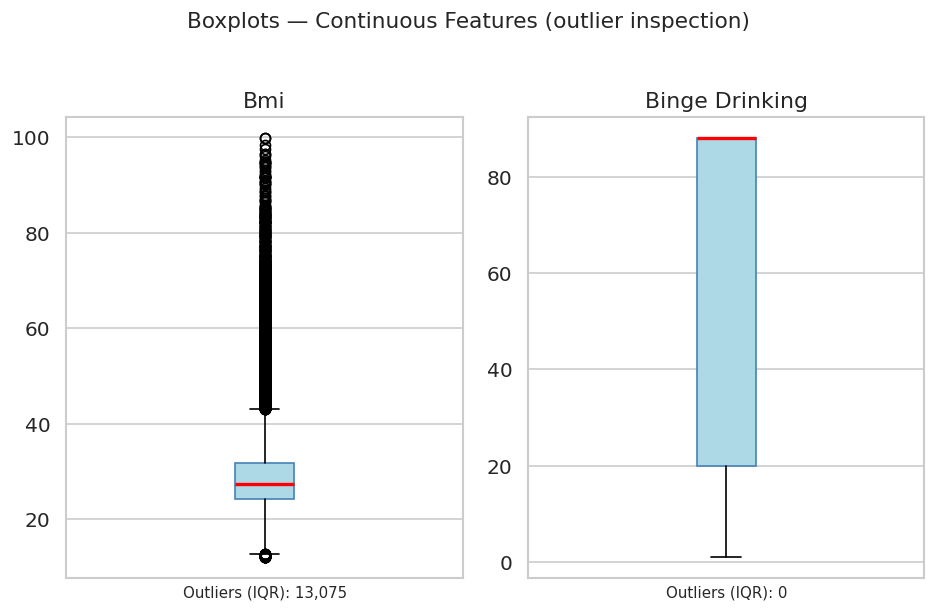

Figure saved: figures/boxplots_outliers.png


In [15]:
fig, axes = plt.subplots(1, len(continuous_cluster), figsize=(4 * len(continuous_cluster), 5))

for ax, col in zip(axes, continuous_cluster):
    data = df[col].dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xticks([])

    # IQR outlier count
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f'Outliers (IQR): {n_out:,}', fontsize=9)

plt.suptitle('Boxplots — Continuous Features (outlier inspection)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}boxplots_outliers.png', bbox_inches='tight')
plt.show()
print('Figure saved: figures/boxplots_outliers.png')

---
## 7. Correlation Analysis

A heatmap of pairwise correlations among clustering features helps us:
- Identify **redundant features** (high correlation → may be dropped or reduced via PCA)
- Spot **expected associations** (e.g., BMI ↔ diabetes, smoking ↔ COPD)

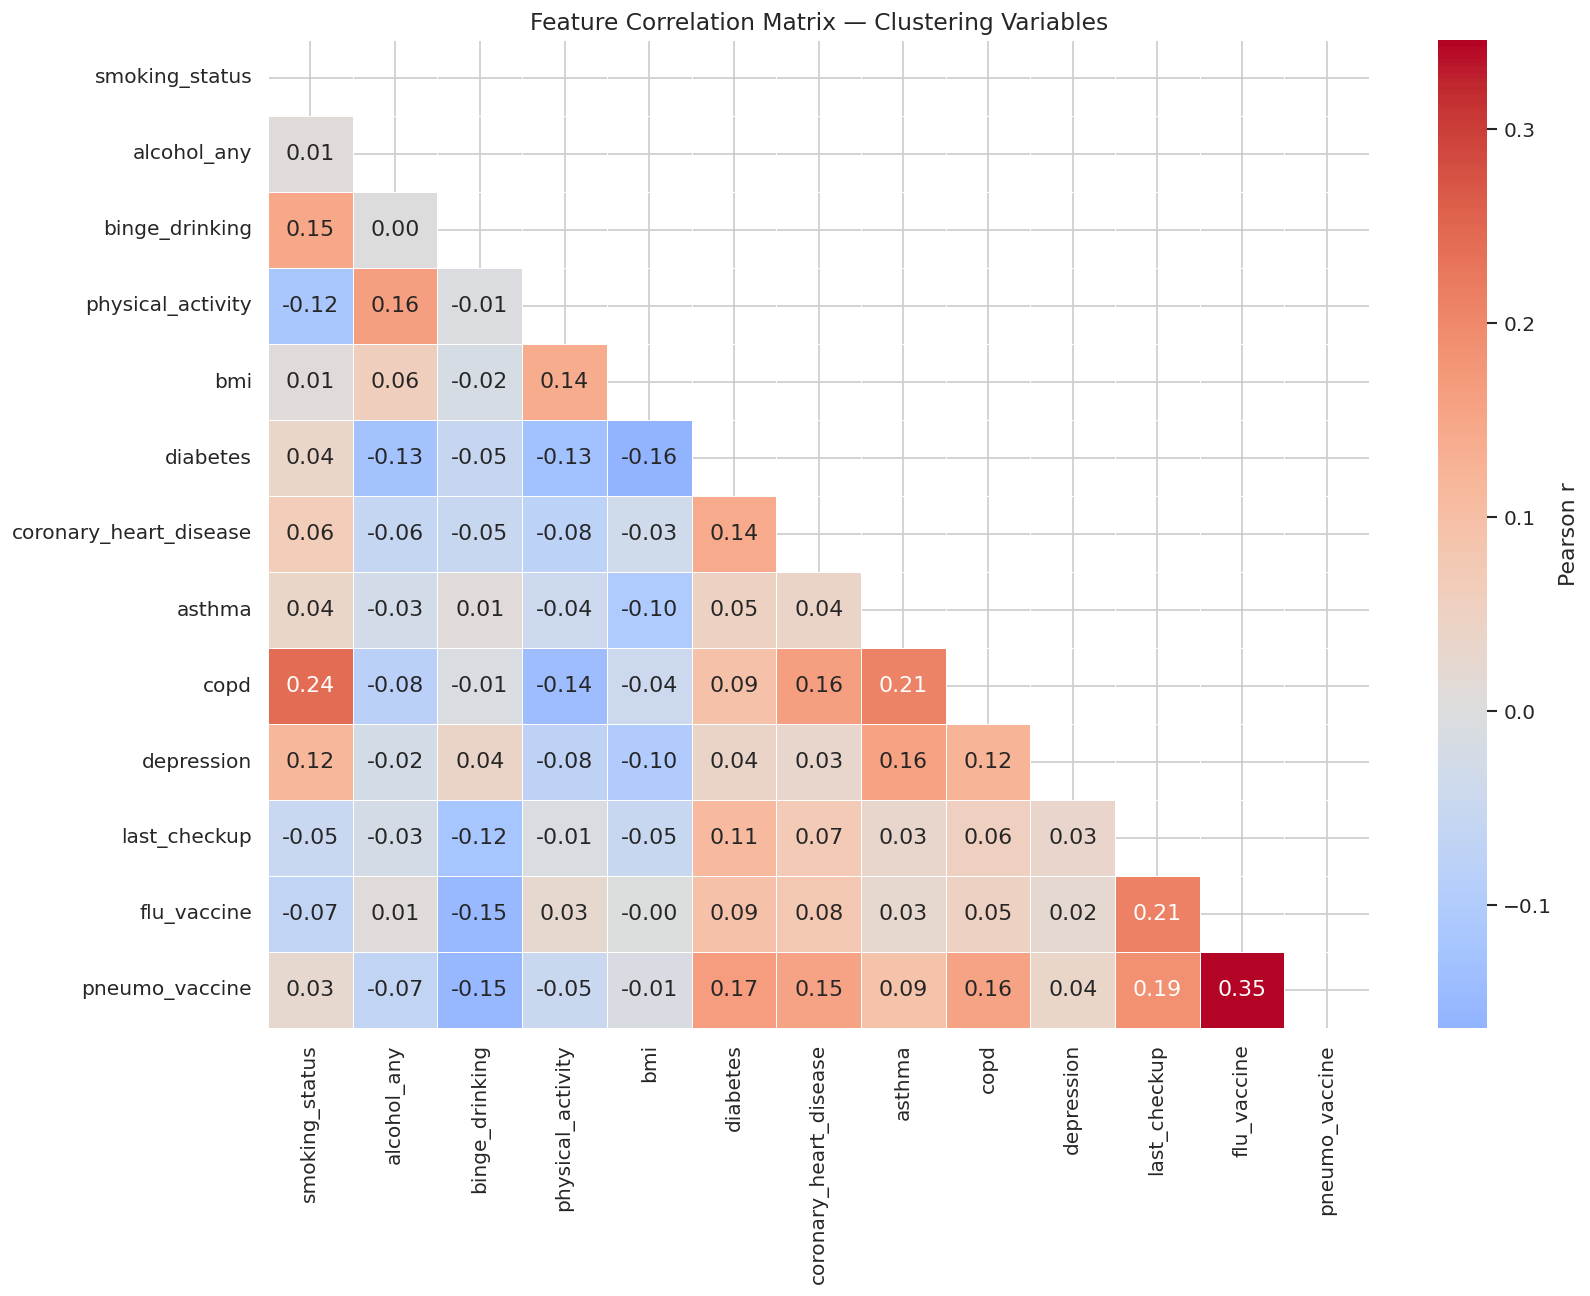

Figure saved: figures/correlation_heatmap.png


In [16]:
corr = df[cluster_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Feature Correlation Matrix — Clustering Variables', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved: figures/correlation_heatmap.png')

---
## 8. Sampling Strategy

The full BRFSS dataset has ~400,000 rows. Hierarchical Clustering is **O(n²)** in memory
and time — infeasible at full scale. Following the challenge guidelines:

- **K-Means & DBSCAN** → run on a stratified sample of **30,000 rows**
- **Hierarchical Clustering** → run on a stratified sample of **5,000 rows** (as per challenge notes)

We stratify by `smoking_status` to preserve the behavioral distribution.

In [17]:
# Drop rows missing the stratification variable
df_valid = df.dropna(subset=['smoking_status']).copy()

# Stratified sample — 30k for K-Means & DBSCAN
df_sample = df_valid.groupby('smoking_status', group_keys=False).apply(
    lambda x: x.sample(frac=30000 / len(df_valid), random_state=RANDOM_SEED)
).reset_index(drop=True)

# Cap at exactly 30,000 in case of rounding
df_sample = df_sample.sample(n=min(30000, len(df_sample)), random_state=RANDOM_SEED)

print(f'Full dataset (after removing missing strat. var): {len(df_valid):,} rows')
print(f'Sample for K-Means & DBSCAN                    : {len(df_sample):,} rows')

# Verify smoking distribution is preserved
print('\nSmoking distribution (original vs sample):')
orig_dist  = df_valid['smoking_status'].value_counts(normalize=True).sort_index()
samp_dist  = df_sample['smoking_status'].value_counts(normalize=True).sort_index()
pd.DataFrame({'Original %': (orig_dist*100).round(1),
              'Sample %'  : (samp_dist*100).round(1)})

Full dataset (after removing missing strat. var): 425,648 rows
Sample for K-Means & DBSCAN                    : 29,999 rows

Smoking distribution (original vs sample):


,Original %,Sample %
smoking_status,,
1.0,7.8,7.8
2.0,3.3,3.3
3.0,28.1,28.1
4.0,60.8,60.8


In [18]:
# Save samples for use in Notebook 02
df_sample.to_csv('../data/brfss_sample_30k.csv', index=False)

# 5k sample for Hierarchical Clustering
df_sample_5k = df_sample.sample(n=5000, random_state=RANDOM_SEED).reset_index(drop=True)
df_sample_5k.to_csv('../data/brfss_sample_5k.csv', index=False)

print('Saved: data/brfss_sample_30k.csv')
print('Saved: data/brfss_sample_5k.csv')

Saved: data/brfss_sample_30k.csv
Saved: data/brfss_sample_5k.csv


---
## 9. EDA Summary & Preprocessing Decisions

This cell produces a written summary of our findings to paste into the IEEE paper.

In [19]:
print('=' * 65)
print('EDA SUMMARY — Challenge 5, Group 3')
print('=' * 65)
print(f"""
Dataset      : CDC BRFSS 2023
Raw shape    : {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns
Selected     : {len(cluster_cols)} clustering features + {len(DEMO_VARS)} demographic features

Key findings:
  • [Fill after running] % of respondents report no physical activity.
  • [Fill after running] % have diagnosed hypertension.
  • BMI is right-skewed; extreme values (>60) exist and will be capped.
  • sleep_hours has a narrow distribution (mode=7h) but outliers at <4h and >12h.
  • binge_drinking is heavily zero-inflated — most respondents report 0 occasions.
  • High missingness (>20%) in: [fill after running] → will be dropped or imputed.

Preprocessing plan (Notebook 02):
  1. Drop features with >40% missing values.
  2. Impute remaining NaNs: median for continuous, mode for categorical.
  3. Binary-encode yes/no variables (1=yes → 1, 2=no → 0).
  4. Cap BMI outliers at 99th percentile.
  5. Apply StandardScaler to all features before clustering.
  6. Apply PCA retaining ≥90% variance for a dimensionality-reduced comparison.
""")
print('=' * 65)

EDA SUMMARY — Challenge 5, Group 3

Dataset      : CDC BRFSS 2023
Raw shape    : 457,670 rows × 19 columns
Selected     : 13 clustering features + 6 demographic features

Key findings:
  • [Fill after running] % of respondents report no physical activity.
  • [Fill after running] % have diagnosed hypertension.
  • BMI is right-skewed; extreme values (>60) exist and will be capped.
  • sleep_hours has a narrow distribution (mode=7h) but outliers at <4h and >12h.
  • binge_drinking is heavily zero-inflated — most respondents report 0 occasions.
  • High missingness (>20%) in: [fill after running] → will be dropped or imputed.

Preprocessing plan (Notebook 02):
  1. Drop features with >40% missing values.
  2. Impute remaining NaNs: median for continuous, mode for categorical.
  3. Binary-encode yes/no variables (1=yes → 1, 2=no → 0).
  4. Cap BMI outliers at 99th percentile.
  5. Apply StandardScaler to all features before clustering.
  6. Apply PCA retaining ≥90% variance for a dimensio

---
## ✅ End of Notebook 01 — EDA

**Next step:** `02_preprocessing.ipynb` — cleaning, encoding, scaling, and PCA.

Files produced:
- `data/brfss_sample_30k.csv` — sample for K-Means & DBSCAN
- `data/brfss_sample_5k.csv`  — sample for Hierarchical Clustering
- `figures/missing_values.png`
- `figures/distributions_continuous.png`
- `figures/distributions_categorical.png`
- `figures/boxplots_outliers.png`
- `figures/correlation_heatmap.png`